# Seller Analysis

This notebook analyzes seller distribution, shipping performance, product category coverage, sales performance, and geographic markets in the Olist e-commerce dataset using PostgreSQL.

The analysis focuses on:

- Seller distribution by state
- Average shipping time by seller
- Number of product categories handled by sellers
- Average sales per order by seller
- Top markets of the highest-revenue sellers

All analytical calculations are performed in SQL, while Python is used for data retrieval and visualization.

In [1]:
import getpass
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, URL

password = getpass.getpass("PostgreSQL password: ")

connection_url = URL.create(
    "postgresql+psycopg2",
    username="laraolgun",
    password=password,
    host="localhost",
    database="olist"
)

engine = create_engine(connection_url)

print("Connected to PostgreSQL: olist")

Connected to PostgreSQL: olist


## 1. Seller Distribution by State

In [2]:
query = """
SELECT
    seller_state,
    COUNT(*) AS number_of_sellers
FROM sellers
GROUP BY seller_state
ORDER BY number_of_sellers DESC;
"""

df_sellers_state = pd.read_sql_query(query, engine)

df_sellers_state

,seller_state,number_of_sellers
0,SP,1849
1,PR,349
2,MG,244
3,SC,190
4,RJ,171
5,RS,129
6,GO,40
7,DF,30
8,ES,23
9,BA,19


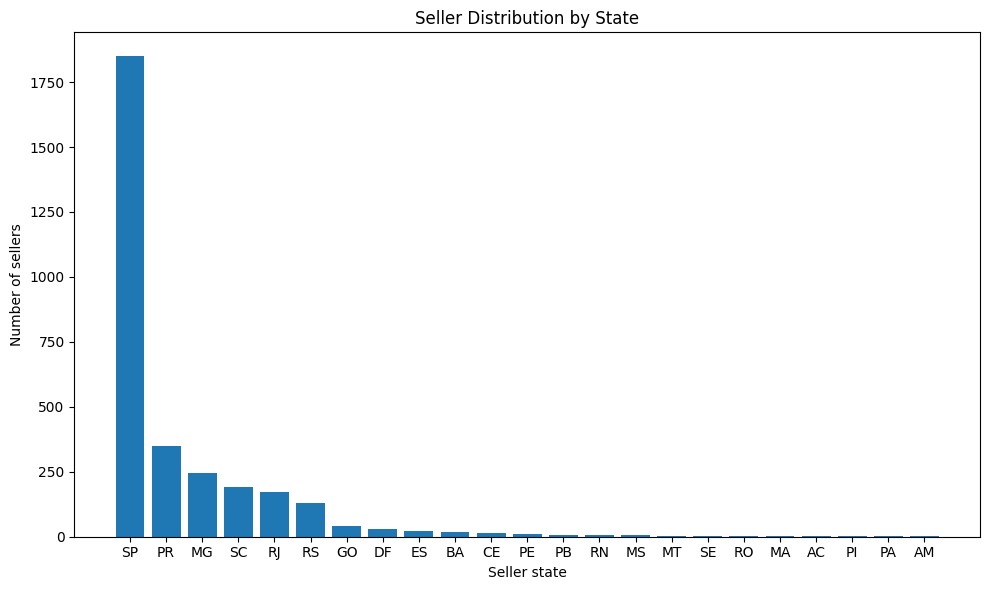

In [3]:
plt.figure(figsize=(10, 6))

plt.bar(
    df_sellers_state["seller_state"],
    df_sellers_state["number_of_sellers"]
)

plt.xlabel("Seller state")
plt.ylabel("Number of sellers")
plt.title("Seller Distribution by State")

plt.tight_layout()
plt.show()

## 2. Top 5 Sellers by Average Shipping Time

In [6]:
query = """
SELECT
    seller_id,
    ROUND(
        AVG(
            EXTRACT(
                EPOCH FROM (
                    o.order_delivered_carrier - o.order_purchase
                )
            ) / 86400.0
        )::numeric,
        2
    ) AS avg_shipping_days
FROM order_items oi
JOIN orders o
    ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_carrier IS NOT NULL
  AND o.order_purchase IS NOT NULL
  AND o.order_delivered_carrier >= o.order_purchase
GROUP BY seller_id
HAVING COUNT(*) >= 10
ORDER BY avg_shipping_days
LIMIT 5;
"""

df_shipping_time = pd.read_sql_query(query, engine)

df_shipping_time

,seller_id,avg_shipping_days
0,7ff588a03c2aeae4fbd23f9ae64b760d,0.51
1,079d295dcbf06ee8bb1b65ba964eb2b6,0.71
2,525e75a6fb1454a2325ab1734bcec221,0.79
3,5b85809efd0d0e4dea1a9544e1280ed9,0.83
4,b494891378bd8f4560abe576c52deacd,0.91


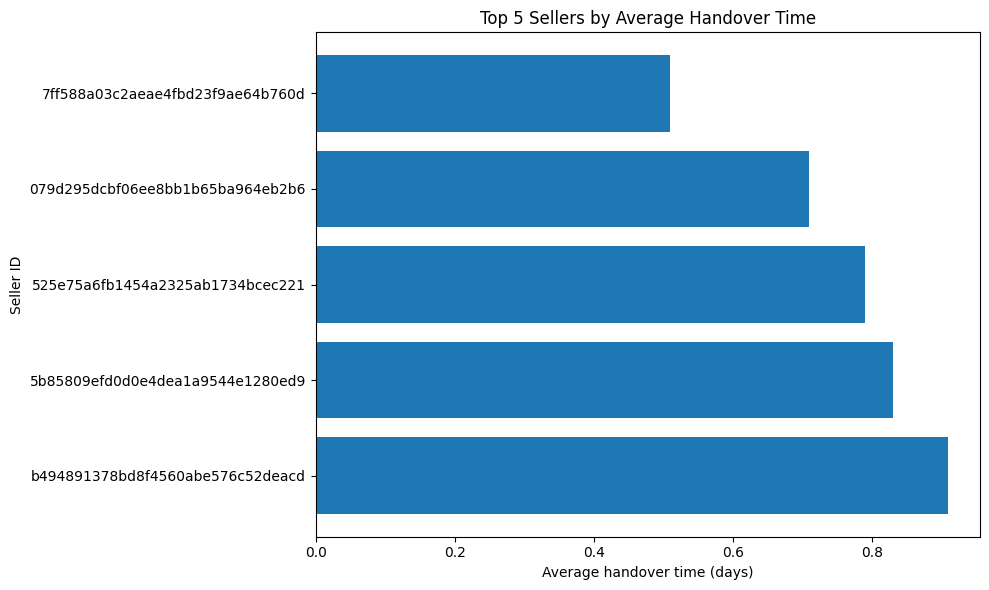

In [8]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_shipping_time["seller_id"].astype(str)[::-1],
    df_shipping_time["avg_shipping_days"][::-1]
)

plt.xlabel("Average handover time (days)")
plt.ylabel("Seller ID")
plt.title("Top 5 Sellers by Average Handover Time")

plt.tight_layout()
plt.show()

## 3. Product Categories per Seller

In [9]:
query = """
WITH seller_categories AS (
    SELECT
        s.seller_id,
        COUNT(DISTINCT p.product_category) AS category_count
    FROM sellers s
    JOIN order_items oi
        ON s.seller_id = oi.seller_id
    JOIN products p
        ON oi.product_id = p.product_id
    WHERE p.product_category IS NOT NULL
    GROUP BY s.seller_id
)
SELECT
    ROUND(AVG(category_count)::numeric, 2) AS avg_categories,
    PERCENTILE_CONT(0.5)
        WITHIN GROUP (ORDER BY category_count) AS median_categories
FROM seller_categories;
"""

df_seller_categories = pd.read_sql_query(query, engine)

df_seller_categories

,avg_categories,median_categories
0,2.1,1.0


## 4. Average Order Revenue by Seller

In [10]:
query = """
WITH seller_order_revenue AS (
    SELECT
        oi.seller_id,
        oi.order_id,
        SUM(oi.price) AS order_revenue
    FROM order_items oi
    GROUP BY oi.seller_id, oi.order_id
)
SELECT
    seller_id,
    ROUND(AVG(order_revenue)::numeric, 2) AS avg_order_revenue,
    COUNT(*) AS number_of_orders
FROM seller_order_revenue
GROUP BY seller_id
HAVING COUNT(*) >= 10
ORDER BY avg_order_revenue DESC
LIMIT 10;
"""

df_seller_avg_order = pd.read_sql_query(query, engine)

df_seller_avg_order

,seller_id,avg_order_revenue,number_of_orders
0,59417c56835dd8e2e72f91f809cd4092,2025.50,18
1,40db9e9aa57f7bb151bcda6b0f9bdbb7,1930.67,12
2,2bf6a2c1e71bbd29a4ad64e6d3c3629f,1687.63,30
3,c3acdfac4e3e97ff87529454fbc03642,1399.00,12
4,b1b3948701c5c72445495bd161b83a4c,1372.18,18
5,b839e41795b7f3ad94cc2014a52f6796,1297.85,33
6,f08a5b9dd6767129688d001acafc21e5,1279.06,11
7,ba90964cff9b9e0e6f32b23b82465f7b,1163.49,38
8,87b740daf17b5d1be335a64164ec6842,1130.76,13
9,ff69aa92bb6b1bf9b8b7a51c2ed9cf8b,1097.04,20


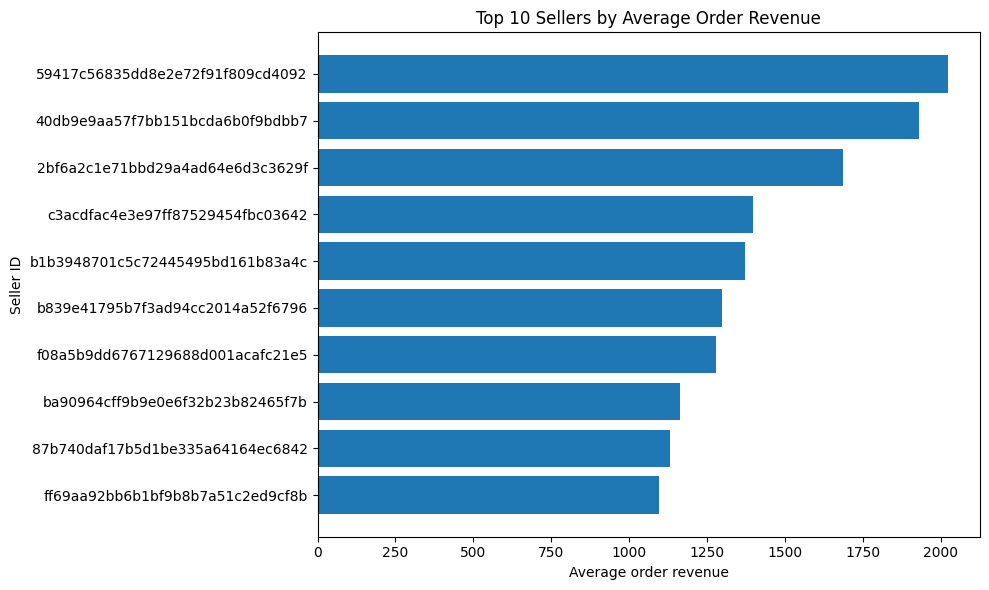

In [11]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_seller_avg_order["seller_id"].astype(str)[::-1],
    df_seller_avg_order["avg_order_revenue"][::-1]
)

plt.xlabel("Average order revenue")
plt.ylabel("Seller ID")
plt.title("Top 10 Sellers by Average Order Revenue")

plt.tight_layout()
plt.show()

## 5. Top 3 Markets of the Top 5 Sellers

In [12]:
query = """
WITH seller_revenue AS (
    SELECT
        oi.seller_id,
        SUM(oi.price) AS total_revenue
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY oi.seller_id
),
top_sellers AS (
    SELECT
        seller_id,
        total_revenue
    FROM seller_revenue
    ORDER BY total_revenue DESC
    LIMIT 5
),
seller_market_revenue AS (
    SELECT
        oi.seller_id,
        c.customer_state,
        SUM(oi.price) AS state_revenue
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    JOIN customers c
        ON o.customer_id = c.customer_id
    JOIN top_sellers ts
        ON oi.seller_id = ts.seller_id
    WHERE o.order_status = 'delivered'
    GROUP BY oi.seller_id, c.customer_state
),
ranked_markets AS (
    SELECT
        seller_id,
        customer_state,
        ROUND(state_revenue::numeric, 2) AS state_revenue,
        RANK() OVER (
            PARTITION BY seller_id
            ORDER BY state_revenue DESC
        ) AS market_rank
    FROM seller_market_revenue
)
SELECT
    seller_id,
    customer_state,
    state_revenue,
    market_rank
FROM ranked_markets
WHERE market_rank <= 3
ORDER BY seller_id, market_rank;
"""

df_top_seller_markets = pd.read_sql_query(query, engine)

df_top_seller_markets

,seller_id,customer_state,state_revenue,market_rank
0,4869f7a5dfa277a7dca6462dcf3b52b2,SP,87233.2,1
1,4869f7a5dfa277a7dca6462dcf3b52b2,RJ,38128.0,2
2,4869f7a5dfa277a7dca6462dcf3b52b2,MG,23977.0,3
3,4a3ca9315b744ce9f8e9374361493884,SP,86315.7,1
4,4a3ca9315b744ce9f8e9374361493884,RJ,29103.2,2
5,4a3ca9315b744ce9f8e9374361493884,MG,25702.3,3
6,53243585a1d6dc2643021fd1853d8905,SP,55764.1,1
7,53243585a1d6dc2643021fd1853d8905,RJ,27671.8,2
8,53243585a1d6dc2643021fd1853d8905,MG,25222.8,3
9,7c67e1448b00f6e969d365cea6b010ab,SP,73420.8,1


In [13]:
engine.dispose()